<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_8/MINE_4210_ADL_202620_L8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)

# **Laboratorio 8: BERT + BertViz**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Comprensión de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación de los datos](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Modelamiento](#scrollTo=wCS6xYiU4YYs&line=1&uniqifier=1)<br>
[4. Evaluación](#scrollTo=nnCc67Uf5urd&line=1&uniqifier=1)<br>
[5. Mapas de atención BertViz](#scrollTo=52G-zC-3DTEj&line=1&uniqifier=1)<br>
[6. Preguntas](#scrollTo=8Z94PZwqmXeI&line=1&uniqifier=1)<br>

### **Contexto y Objetivos**

**Problema**
- Se requiere realizar el análisis de sentimientos de un conjunto de frases del sector financiero como parte de la evaluación del sentimiento del mercado y la reputación de empresas, con el objetivo de tomar decisiones de inversión informadas.

**Objetivos**
1. Construir una Red Neuronal basada en una arquitectura Transformers para llevar a cabo un análisis de sentimientos, ejemplificando así la aplicación de modelos de procesamiento del lenguaje natural.
2. Ver cómo se comporta la atención con BertViz para definir la clasificación del sentimiento.


**Datos**

Los datos los puedes consultar [aquí](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis).

In [ ]:
!pip install bertviz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de TensorFlow y Keras
import tensorflow as tf
import tf_keras as keras
import tensorflow_hub as hub
import tensorflow_text as text

from bertviz import head_view, model_view
from transformers import BertTokenizer, BertModel

from tf_keras.models import Sequential
from tf_keras.callbacks import EarlyStopping
from tf_keras.layers import Input, Dense, Dropout, LSTM, Flatten

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from google.colab import files
from google.colab import userdata

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### **1. Comprensión de los datos**

Para entender cómo traemos los datos desde kaggle pueden revisar este [link](https://www.kaggle.com/discussions/general/51898#520673)

In [ ]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d sbhatti/financial-sentiment-analysis

! unzip "financial-sentiment-analysis.zip"

Dataset URL: https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis
License(s): CC0-1.0
100% 276k/276k [00:00<00:00, 41.8MB/s]

Archive:  financial-sentiment-analysis.zip
  inflating: data.csv                


In [ ]:
data = pd.read_csv('/content/data.csv', sep=',')
data

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


In [ ]:
# Veamos la distribución del sentimiento
data["Sentiment"].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


### **2. Preparación de los datos**

Debemos usar un `LabelEncoder()` para poder asignar correctamente nuestros tópicos a las neuronas de salida.

In [ ]:
label_encoder = LabelEncoder()
data['Sentiment'] = label_encoder.fit_transform(data['Sentiment'])

etiquetas_unicas = label_encoder.classes_
for valor_numerico, etiqueta_original in enumerate(etiquetas_unicas):
    print(f'Valor numérico: {valor_numerico}, Etiqueta original: {etiqueta_original}')

Valor numérico: 0, Etiqueta original: negative
Valor numérico: 1, Etiqueta original: neutral
Valor numérico: 2, Etiqueta original: positive


In [ ]:
# Divide los datos en entrenamiento y prueba
train, test = train_test_split(data, test_size=0.2, stratify=data['Sentiment'], random_state=42, shuffle = True)

# Ahora divide el conjunto de entrenamiento en entrenamiento y validación
train, val = train_test_split(train, test_size=0.2, stratify=train['Sentiment'], random_state=42, shuffle = True)

print("Tamaño de datos de entrenamiento:", train.shape)
print("Tamaño de datos de validación:", val.shape)
print("Tamaño de datos de prueba:", test.shape)

train

Tamaño de datos de entrenamiento: (3738, 2)
Tamaño de datos de validación: (935, 2)
Tamaño de datos de prueba: (1169, 2)


,Sentence,Sentiment
3097,"Digia will also set up two subsidiaries , Digi...",1
5048,$BBRY Sierra. Has a great cash balance and imp...,2
5727,"Britain's FTSE gains, Land Securities up after...",2
185,The Finnish company sold its UK operation - co...,1
4265,Russian Media Ventures ' minority shareholder ...,1
...,...,...
326,( I&H ) in a move to enhance growth .,2
2821,"In addition , a further 29 employees can be la...",0
4365,"The paper industry 's de-inking sludge , which...",1
1603,$JE LOOKS like we are bouncing. Would be nice...,2


In [ ]:
X_train, X_test, X_val= train['Sentence'], test['Sentence'], val['Sentence']
y_train, y_test, y_val= train['Sentiment'], test['Sentiment'], val['Sentiment']

print("x_train", X_train.shape, " y_train:", y_train.shape)
print("x_test:", X_test.shape, "y_test", y_test.shape)
print("x_val", X_val.shape, "y_val:", y_val.shape)

x_train (3738,)  y_train: (3738,)
x_test: (1169,) y_test (1169,)
x_val (935,) y_val: (935,)


### **3. Modelamiento**

In [ ]:
# Cargar los modelos de TensorFlow Hub con trainable=True si deseas fine-tuning
bert_preprocess_model = hub.KerasLayer(
    "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3",
    name='preprocessing'
)

bert_model = hub.KerasLayer(
    "https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/2",
    trainable=False, # Solo como extractor de características
    name='BERT_encoder'
)

print(f'BERT model selected: {bert_model}')
print(f'Preprocess model selected: {bert_preprocess_model}')

BERT model selected: <tensorflow_hub.keras_layer.KerasLayer object at 0x7ccde351a210>
Preprocess model selected: <tensorflow_hub.keras_layer.KerasLayer object at 0x7ccde36e6e40>


In [ ]:
# Capas Bert
text_input = keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessing_output = bert_preprocess_model(text_input)
outputs = bert_model(preprocessing_output)

# Capas de nuestra red adicional
l = keras.layers.Dense(512, activation='relu', name="capaOculta1")(outputs['pooled_output'])
l = keras.layers.Dropout(0.3, name="dropout1")(l)

l = keras.layers.Dense(256, activation='relu', name="capaOculta2")(l)
l = keras.layers.Dropout(0.3, name="dropout2")(l)

l = keras.layers.Dense(128, activation='relu', name="capaOculta3")(l)
l = keras.layers.Dropout(0.2, name="dropout3")(l)

l = keras.layers.Dense(64, activation='relu', name="capaOculta4")(l)
l = keras.layers.Dropout(0.2, name="dropout4")(l)

y = keras.layers.Dense(3, activation='softmax', name="output")(l)

# Usamos inputs y outputs para construir el modelo final
model = keras.Model(inputs=[text_input], outputs = [y])

In [ ]:
metrics = ['accuracy']

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=metrics)

In [ ]:
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_word_ids': (None,                                            
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             }                                                                

In [ ]:
history = model.fit(X_train, y_train,
          validation_data = (X_val, y_val),
          epochs=20,
          callbacks= EarlyStopping(monitor='val_accuracy', patience=4)
          )

Epoch 1/20
117/117 [==============================] - 43s 203ms/step - loss: 0.9294 - accuracy: 0.5714 - val_loss: 0.8218 - val_accuracy: 0.5989
Epoch 2/20
117/117 [==============================] - 18s 154ms/step - loss: 0.8393 - accuracy: 0.6134 - val_loss: 0.7787 - val_accuracy: 0.5968
Epoch 3/20
117/117 [==============================] - 19s 166ms/step - loss: 0.8026 - accuracy: 0.6231 - val_loss: 0.7615 - val_accuracy: 0.6321
Epoch 4/20
117/117 [==============================] - 20s 166ms/step - loss: 0.7672 - accuracy: 0.6388 - val_loss: 0.7523 - val_accuracy: 0.6471
Epoch 5/20
117/117 [==============================] - 21s 180ms/step - loss: 0.7617 - accuracy: 0.6413 - val_loss: 0.7537 - val_accuracy: 0.6225
Epoch 6/20
117/117 [==============================] - 21s 180ms/step - loss: 0.7234 - accuracy: 0.6549 - val_loss: 0.7008 - val_accuracy: 0.6727
Epoch 7/20
117/117 [==============================] - 21s 177ms/step - loss: 0.7113 - accuracy: 0.6645 - val_loss: 0.6953 - val_ac

**Veamos los resultados de nuestro modelo con los datos de entrenamiento**

In [ ]:
classes_names = label_encoder.classes_
y_pred = model.predict(X_train)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_train, y_pred, target_names = classes_names))

117/117 [==============================] - 8s 68ms/step
              precision    recall  f1-score   support

    negative       0.56      0.36      0.44       550
     neutral       0.76      0.92      0.83      2003
    positive       0.77      0.62      0.69      1185

    accuracy                           0.74      3738
   macro avg       0.69      0.63      0.65      3738
weighted avg       0.73      0.74      0.73      3738



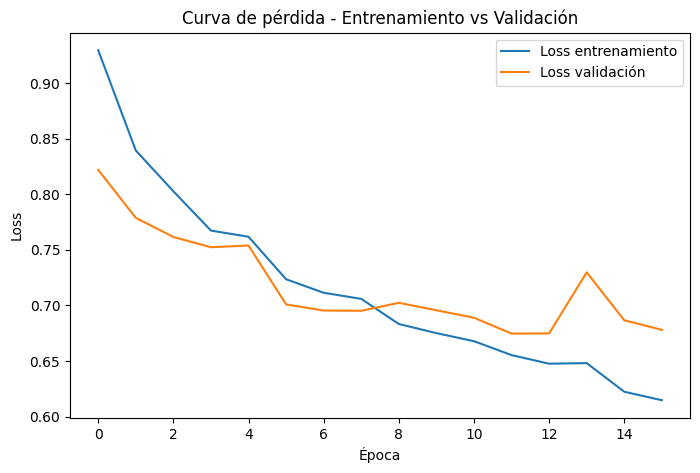

In [ ]:
# Veamos el loss entre train y val
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida - Entrenamiento vs Validación')
plt.legend()
plt.show()

### **4. Evaluación**

37/37 [==============================] - 3s 88ms/step
              precision    recall  f1-score   support

    negative       0.29      0.20      0.24       172
     neutral       0.73      0.88      0.80       626
    positive       0.69      0.53      0.60       371

    accuracy                           0.67      1169
   macro avg       0.57      0.54      0.55      1169
weighted avg       0.65      0.67      0.65      1169



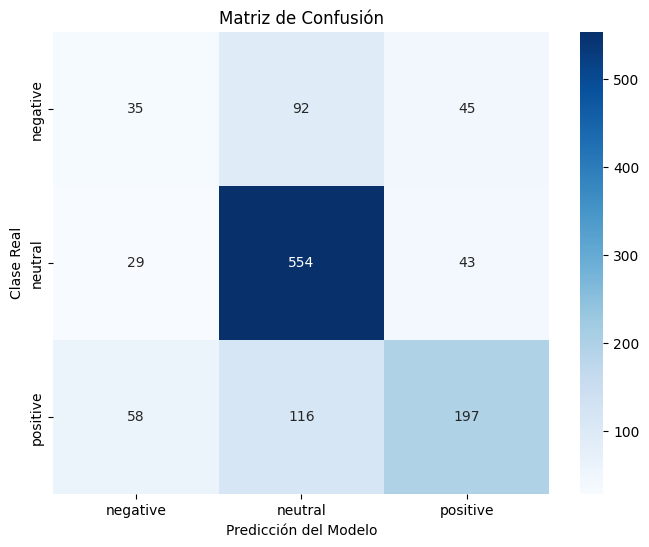

In [ ]:
# Veamos en test
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test
print(classification_report(y_true_classes, y_pred_classes, target_names = classes_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes_names,
    yticklabels=classes_names
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.title("Matriz de Confusión")
plt.show()

### **5. Mapas de atención con BertViz**

In [ ]:
# Tomemos una frase negativa y una positiva
cod_neg = list(label_encoder.classes_).index('negative')
cod_pos = list(label_encoder.classes_).index('positive')
frase_negativa = data[data['Sentiment'] == cod_neg]['Sentence'].sample(1, random_state=42).iloc[0]
frase_positiva = data[data['Sentiment'] == cod_pos]['Sentence'].sample(1, random_state=42).iloc[0]
print("NEGATIVA:", frase_negativa)
print("POSITIVA:", frase_positiva)

NEGATIVA: `` Adjustment to the fall in price level , in contrast , has been less effective .
POSITIVA: Sales VAT inclusive expanded by 19 percent , to 351 million euros .


In [ ]:
# Definimos los atributos necesarios para ver los mapas de atención
hf_model_name = "google/bert_uncased_L-4_H-512_A-8"
tokenizer_hf = BertTokenizer.from_pretrained(hf_model_name)
model_hf = BertModel.from_pretrained(
    hf_model_name,
    output_attentions=True,
    attn_implementation="eager"
)
model_hf.eval()

def visualizar_atencion(sentence, tokenizer_hf, model_hf):
    inputs = tokenizer_hf.encode(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model_hf(inputs)
    attention = outputs.attentions
    tokens = tokenizer_hf.convert_ids_to_tokens(inputs[0])
    print(f"Frase: {sentence}")
    print(f"Tokens: {tokens}")
    model_view(attention, tokens)

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  116MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/bert_uncased_L-4_H-512_A-8
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print("=== Ejemplo NEGATIVO ===")
visualizar_atencion(frase_negativa, tokenizer_hf, model_hf)

=== Ejemplo NEGATIVO ===
Frase: `` Adjustment to the fall in price level , in contrast , has been less effective .
Tokens: ['[CLS]', '`', '`', 'adjustment', 'to', 'the', 'fall', 'in', 'price', 'level', ',', 'in', 'contrast', ',', 'has', 'been', 'less', 'effective', '.', '[SEP]']


<IPython.core.display.Javascript object>

In [ ]:
print("=== Ejemplo POSITIVO ===")
visualizar_atencion(frase_positiva, tokenizer_hf, model_hf)

=== Ejemplo POSITIVO ===
Frase: Sales VAT inclusive expanded by 19 percent , to 351 million euros .
Tokens: ['[CLS]', 'sales', 'va', '##t', 'inclusive', 'expanded', 'by', '19', 'percent', ',', 'to', '351', 'million', 'euros', '.', '[SEP]']


<IPython.core.display.Javascript object>

- Cada línea conecta un token (izquierda) con otro (derecha), el grosor/intensidad indica cuánta atención le presta uno al otro en esa cabeza y capa específica.
- Veamos cómo las relaciones se intensifican en palabras que normalmente conocemos como negativas y positivas.
- Al final la atención muestra a dónde mira el modelo, no necesariamente el por qué decide el sentimiento. No hay una relación causal, es solo una forma visual para ver cómo se comporta en sus mecanismos de atención.

### **6. Preguntas**

1. El modelo tiene un recall de 0.20 para la clase negativa en test y de 0.36 en entrenamiento. ¿Se trata de sobreajuste o de bajoajuste? Justifica con los resultados del notebook. Propón una modificación, aplícala y compara el macro-F1 y el recall de la clase negativa.

2. Activa trainable=True y realiza un fine-tuning con una tasa de aprendizaje baja (por ejemplo, 2e-5) y pocas épocas. Compara con el modelo congelado con base en número de parámetros entrenables, tiempo por época, macro-F1 y recall de la clase negativa.

3. Visualiza con BertViz una oración del conjunto de test que el modelo haya clasificado mal y compárala con una bien clasificada. ¿Los mapas de atención permiten explicar por qué el clasificador se equivocó? Ten en cuenta qué modelo se está visualizando y dónde se toma la decisión de clasificación.